### **Recipe for FishSOOP (FVON) data plot around Tasmania**

---
<br>

- This script is a Jupyter Notebook written in Python.

- The purpose of a recipe notebook is to provide an easy introduction for people not necessarilly with much coding knowledge. 

- It can also be a helper for those who already have a strong coding background but are not familar with a specific data analysis. In this case FishSOOP.

- If you're not familar with Python, any AI tool will be your best friend to debug an error or to understand what the code is doing.

- The data used here is located at the "data" folder and was downloaded from the [Australian Ocean Data Network AODN portal beta version](https://portal-beta.aodn.org.au/details/bdb84466-dc53-49ad-a60f-83d9fa0baed5?tab=summary)


⚠️ On the README from the Github repository for this code, you will find a "Open in Colab" button. \
Like this: ![Colab Button](images/colab_button.png)

- Click on it and you will be redirected to the Google Colab webpage where you can interate with the recipe notebook.
- Once on Google Colab, you should be able to successfully run the code after pressing the button "> Run all". 
- You can keep your personal copy on Google Colab to make your own changes.
- This will run the entire code in sequence. But you can also run cell by cell by yourself.

⚠️ After you finish playing/running the recipe go to the tab "Runtime" > "Disconnect and delete runtime", so in the next time you will start a fresh session next time. However, if you want to go to a next level, you can even save your changes in your Colab account.


<u>This recipe will show you how to: </u>
1. Read the data
2. Create a plot with data coordinates on a map
3. Create a timeseries with all the data available
4. Select a time range from the whole time series
5. Create a surface map of depth averaged temperature

<br>

This is the area from where we downloaded the FishSOOP data from AODN portal.

![FishSOOP Area](images/fishsoop_area.png)


---

Author: Fernando Sobral \
Date: 27 Aug 2026 \
UNSW Sydney

---

# Preparing the system to run on Colab

In [ ]:
# Installing libraries to run in Colab. If you saved your previous session in Google Colab or is running locally in your personal computer
# you can comment out this cell.

!pip install cmocean cartopy

In [ ]:
# When running in Colab only. If running in your local computer, comment out this cell.

from pathlib import Path
repo = Path("/content/imos-fishsoop-cookbook")

if repo.exists():
    !git -C /content/imos-fishsoop-cookbook pull
else:
    !git clone https://github.com/UNSW-oceanography/imos-fishsoop-cookbook.git


In [3]:
# Change to current working path
%cd /content/imos-fishsoop-cookbook

[Errno 2] No such file or directory: '/content/imos-fishsoop-cookbook'
/Users/z5392640/repositories/UNSW-oceanography/imos-fishsoop-cookbook


# Starting the script

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from cmocean import cm as cmo
import matplotlib.dates as mdates
import cartopy.crs as ccrs

from aux_fishsoop import *

In [5]:
# Reading CSV data
fishsoop_data = pd.read_csv('data/vessel_fishsoop_realtime_qc/vessel_fishsoop_realtime_qc.csv')

# To display its format - sanity check
fishsoop_data



,TRAJECTORY_ID,TIME,LATITUDE,LATITUDE_quality_control,LONGITUDE,LONGITUDE_quality_control,DEPTH,DEPTH_quality_control,TEMPERATURE,TEMPERATURE_quality_control,PRES,PRES_quality_control,filename,instrument,instrument_serial_number,timestamp,polygon
0,1.0,2026-01-24 06:01:03.000000512,-38.573860,1,141.068787,1,465.534210,1,9.355,1,469.600006,1,IMOS_SOOP-FishSOOP_TP_20260124T085957Z_FV01_82.nc,ZebraTech Moana TD1000,82,1767225600,010300000001000000050000000000000000E060400000...
1,1.0,2026-01-24 06:06:03.000000000,-38.575321,1,141.073227,1,465.435181,1,9.344,1,469.500000,1,IMOS_SOOP-FishSOOP_TP_20260124T085957Z_FV01_82.nc,ZebraTech Moana TD1000,82,1767225600,010300000001000000050000000000000000E060400000...
2,1.0,2026-01-24 06:11:03.000000000,-38.576817,1,141.077560,1,465.138123,1,9.338,1,469.200012,1,IMOS_SOOP-FishSOOP_TP_20260124T085957Z_FV01_82.nc,ZebraTech Moana TD1000,82,1767225600,010300000001000000050000000000000000E060400000...
3,1.0,2026-01-24 06:16:03.000000000,-38.578297,1,141.082001,1,465.633209,1,9.332,1,469.700012,1,IMOS_SOOP-FishSOOP_TP_20260124T085957Z_FV01_82.nc,ZebraTech Moana TD1000,82,1767225600,010300000001000000050000000000000000E060400000...
4,1.0,2026-01-24 06:21:03.000000000,-38.579102,1,141.086639,1,466.128326,1,9.320,1,470.200012,1,IMOS_SOOP-FishSOOP_TP_20260124T085957Z_FV01_82.nc,ZebraTech Moana TD1000,82,1767225600,010300000001000000050000000000000000E060400000...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89934,1.0,2026-08-27 04:07:09.000000000,-43.128342,1,147.959702,1,5.158623,1,13.118,1,5.200000,1,IMOS_SOOP-FishSOOP_TP_20260827T041009Z_FV01_13...,ZebraTech Moana TD200,1352,1785542400,0103000000010000000500000000000000008061400000...
89935,1.0,2026-08-27 04:07:54.000000000,-43.128342,1,147.959702,1,4.067387,1,13.150,1,4.100000,1,IMOS_SOOP-FishSOOP_TP_20260827T041009Z_FV01_13...,ZebraTech Moana TD200,1352,1785542400,0103000000010000000500000000000000008061400000...
89936,1.0,2026-08-27 04:08:02.000000000,-43.128342,1,147.959702,1,2.876940,1,13.142,1,2.900000,1,IMOS_SOOP-FishSOOP_TP_20260827T041009Z_FV01_13...,ZebraTech Moana TD200,1352,1785542400,0103000000010000000500000000000000008061400000...
89937,1.0,2026-08-27 04:08:06.000000000,-43.128342,1,147.959702,1,1.785692,1,13.166,1,1.800000,1,IMOS_SOOP-FishSOOP_TP_20260827T041009Z_FV01_13...,ZebraTech Moana TD200,1352,1785542400,0103000000010000000500000000000000008061400000...


In [6]:
# Applying QC. Selecting only data with FLAG = 1 
fishsoop_qc = fishsoop_data[((fishsoop_data.TEMPERATURE_quality_control == 1) & 
                             (fishsoop_data.DEPTH_quality_control == 1)       & 
                             (fishsoop_data.LATITUDE_quality_control == 1)    & 
                             (fishsoop_data.LONGITUDE_quality_control == 1))]

# Comparing before and after keeping only data flagged = 1
print("Fishsoop data shape before using QC is %s." % str(fishsoop_data.shape))
print("Fishsoop data shape after using QC is %s." % str(fishsoop_qc.shape))


Fishsoop data shape before using QC is (89939, 17).
Fishsoop data shape after using QC is (78757, 17).


## **Plotting the data on a map**

In [7]:
# Finding the coordinate limits of your selected area
# The limits will be used in the "make_map" function from the next cell.
# If your region is too narrow/small, you can extend the limits for a better plot on the map playing with the coordinates below (+ or - some degrees of change)

lon_min = fishsoop_qc.LONGITUDE.min()
lon_max = fishsoop_qc.LONGITUDE.max()
lat_min = fishsoop_qc.LATITUDE.min()
lat_max = fishsoop_qc.LATITUDE.max()

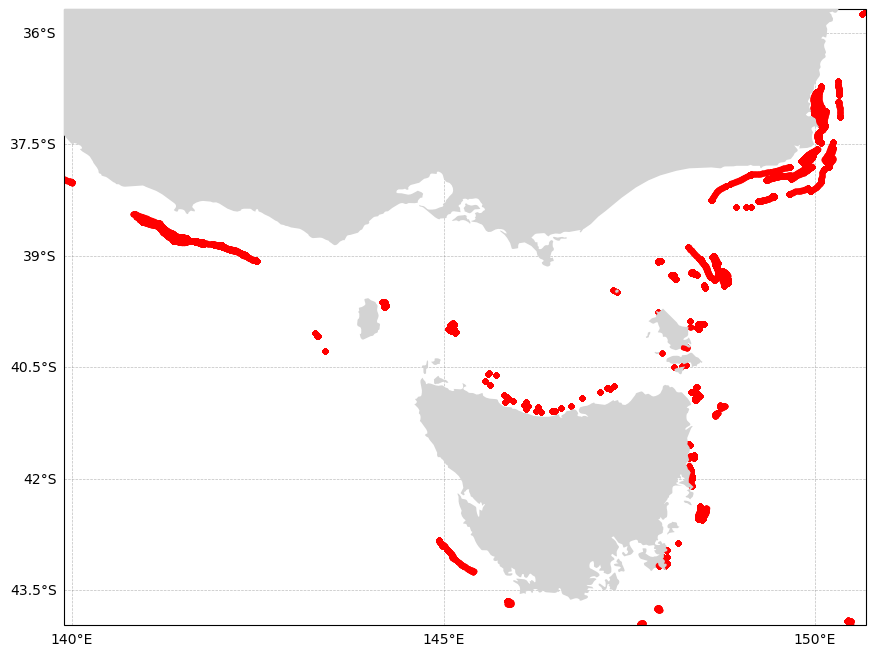

In [8]:
# Plotting the map and all the coordinate points

fig, ax = make_map(lon_min, lon_max, lat_min, lat_max)
ax.plot(fishsoop_qc.LONGITUDE, fishsoop_qc.LATITUDE, '.r', transform=ccrs.PlateCarree())


## **Plotting time series of the casts**

In [9]:
# To avoid problems with TIME conversion

fishsoop_qc["TIME"] = pd.to_datetime(
    fishsoop_qc["TIME"],
    format="mixed"
)

In [10]:
# Selecting filenames so we can have control to select single casts.

casts = fishsoop_qc.filename.unique()

casts[:10]

<ArrowStringArray>
[  'IMOS_SOOP-FishSOOP_TP_20260124T085957Z_FV01_82.nc',
 'IMOS_SOOP-FishSOOP_TP_20260124T092547Z_FV01_1070.nc',
 'IMOS_SOOP-FishSOOP_TP_20260124T112104Z_FV01_1070.nc',
  'IMOS_SOOP-FishSOOP_TP_20260125T032737Z_FV01_863.nc',
   'IMOS_SOOP-FishSOOP_TP_20260124T224152Z_FV01_82.nc',
 'IMOS_SOOP-FishSOOP_TP_20260125T014807Z_FV01_1070.nc',
   'IMOS_SOOP-FishSOOP_TP_20260125T050355Z_FV01_82.nc',
 'IMOS_SOOP-FishSOOP_TP_20260125T115514Z_FV01_1017.nc',
  'IMOS_SOOP-FishSOOP_TP_20260125T213407Z_FV01_947.nc',
 'IMOS_SOOP-FishSOOP_TP_20260125T111125Z_FV01_1070.nc']
Length: 10, dtype: str

In [11]:
# Selecting a single cast

c1 = 10
c2 = 50
c3 = 200
c4 = 500
single_cast1 = fishsoop_qc[fishsoop_qc.filename == casts[c1]]
single_cast2 = fishsoop_qc[fishsoop_qc.filename == casts[c2]]
single_cast3 = fishsoop_qc[fishsoop_qc.filename == casts[c3]]
single_cast4 = fishsoop_qc[fishsoop_qc.filename == casts[c4]]


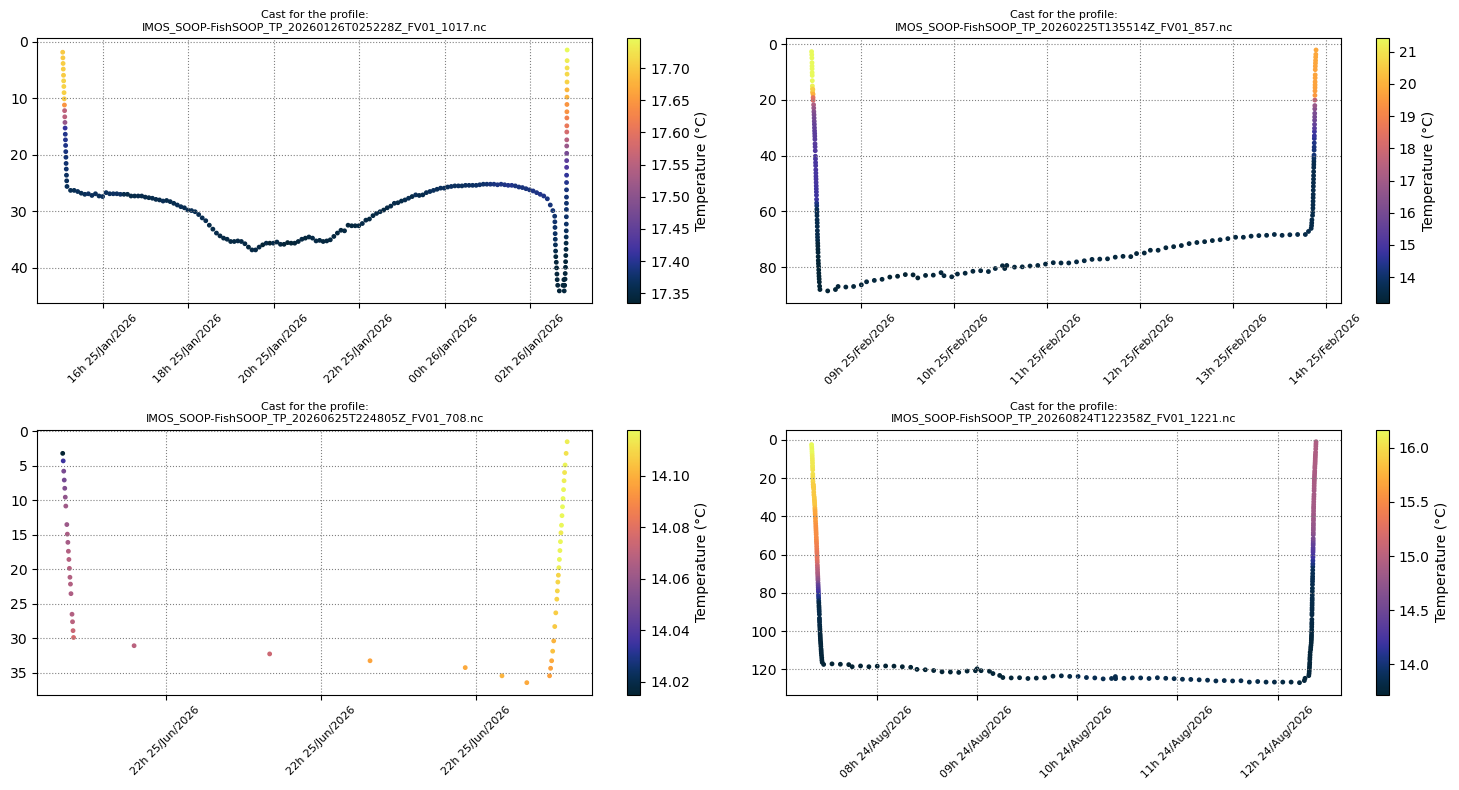

In [12]:
# Plotting four different casts

fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(15, 8))

clb0 = ax[0, 0].scatter(single_cast1.TIME, single_cast1.DEPTH, c=single_cast1.TEMPERATURE, s=6, cmap=cmo.thermal)
clb1 = ax[0, 1].scatter(single_cast2.TIME, single_cast2.DEPTH, c=single_cast2.TEMPERATURE, s=6, cmap=cmo.thermal)
clb2 = ax[1, 0].scatter(single_cast3.TIME, single_cast3.DEPTH, c=single_cast3.TEMPERATURE, s=6, cmap=cmo.thermal)
clb3 = ax[1, 1].scatter(single_cast4.TIME, single_cast4.DEPTH, c=single_cast4.TEMPERATURE, s=6, cmap=cmo.thermal)


ax[0, 0].invert_yaxis()
ax[0, 1].invert_yaxis()
ax[1, 0].invert_yaxis()
ax[1, 1].invert_yaxis()


ax[0, 0].grid(ls=':', color='gray')
ax[0, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Hh %d/%b/%Y"))
ax[0, 1].grid(ls=':', color='gray')
ax[0, 1].xaxis.set_major_formatter(mdates.DateFormatter("%Hh %d/%b/%Y"))
ax[1, 0].grid(ls=':', color='gray')
ax[1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Hh %d/%b/%Y"))
ax[1, 1].grid(ls=':', color='gray')
ax[1, 1].xaxis.set_major_formatter(mdates.DateFormatter("%Hh %d/%b/%Y"))


ax[0, 0].tick_params(axis="x", labelrotation=45, labelsize=8)
ax[0, 1].tick_params(axis="x", labelrotation=45, labelsize=8)
ax[1, 0].tick_params(axis="x", labelrotation=45, labelsize=8)
ax[1, 1].tick_params(axis="x", labelrotation=45, labelsize=8)

ax[0, 0].set_title('Cast for the profile:\n%s' % (casts[c1]), fontsize=8)
ax[0, 1].set_title('Cast for the profile:\n%s' % (casts[c2]), fontsize=8)
ax[1, 0].set_title('Cast for the profile:\n%s' % (casts[c3]), fontsize=8)
ax[1, 1].set_title('Cast for the profile:\n%s' % (casts[c4]), fontsize=8)
cb0 = fig.colorbar(clb0, ax=ax[0, 0])
cb1 = fig.colorbar(clb1, ax=ax[0, 1])
cb2 = fig.colorbar(clb2, ax=ax[1, 0])
cb3 = fig.colorbar(clb3, ax=ax[1, 1])

cb0.set_label("Temperature (°C)")
cb1.set_label("Temperature (°C)")
cb2.set_label("Temperature (°C)")
cb3.set_label("Temperature (°C)")

fig.tight_layout()

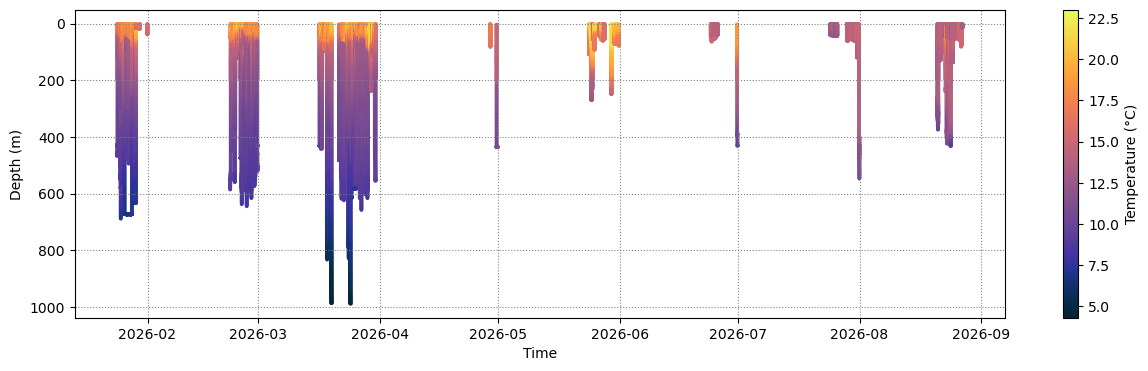

In [13]:
# Plotting the time series

temperature = fishsoop_qc.TEMPERATURE
depth = fishsoop_qc.DEPTH
time = fishsoop_qc.TIME

fig, ax = plt.subplots(figsize=(15, 4))

clb = ax.scatter(time, depth, c=temperature, s=3, cmap=cmo.thermal)
ax.invert_yaxis()
ax.set_ylabel('Depth (m)')
ax.set_xlabel('Time')

ax.grid(ls=':', color='gray')
cb = fig.colorbar(clb, ax=ax)
cb.set_label("Temperature (°C)")

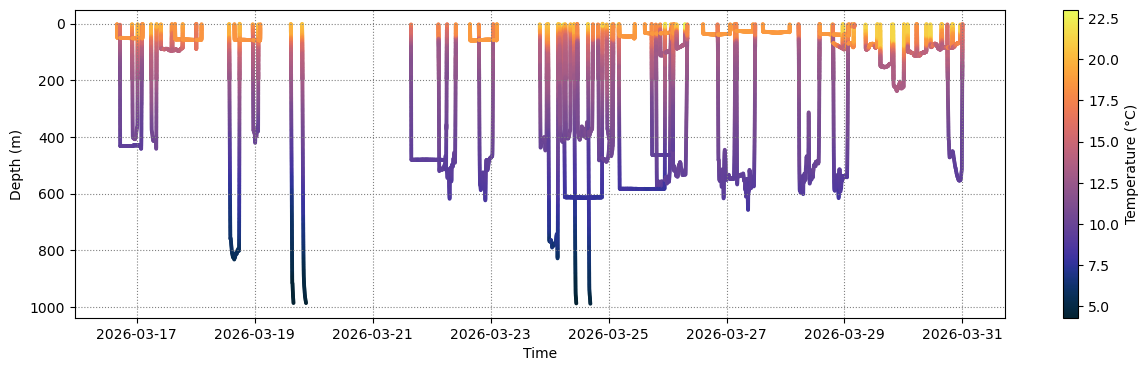

In [14]:
# Selecting a specific time range from the dataset. 
# You can see the time range being selected on the plot aboves
fishsoop_sel = fishsoop_qc[(fishsoop_qc.TIME >= '2026-03-15') & (fishsoop_qc.TIME <= '2026-04-01')]

temperature = fishsoop_sel.TEMPERATURE
depth = fishsoop_sel.DEPTH
time = fishsoop_sel.TIME


# Plotting
fig, ax = plt.subplots(figsize=(15, 4))

clb = ax.scatter(time, depth, c=temperature, s=3, cmap=cmo.thermal)
ax.invert_yaxis()
ax.set_ylabel('Depth (m)')
ax.set_xlabel('Time')

ax.grid(ls=':', color='gray')
cb = fig.colorbar(clb, ax=ax)
cb.set_label("Temperature (°C)")

## **Plotting gridded averaged map**

In [15]:
avg_depth = 100
grid_resol = 0.25
fishsoop_depth_sel = fishsoop_qc[fishsoop_qc.DEPTH <= avg_depth]
st_date = fishsoop_depth_sel.TIME.min().strftime('%d/%b/%Y')
nd_date = fishsoop_depth_sel.TIME.max().strftime('%d/%b/%Y')
extent = [lon_min, lon_max, lat_min, lat_max]

bin_avg, lat_edges, lon_edges = fishsoop_binning_spatialFields(fishsoop_depth_sel, 'TEMPERATURE', grid_resol, extent)


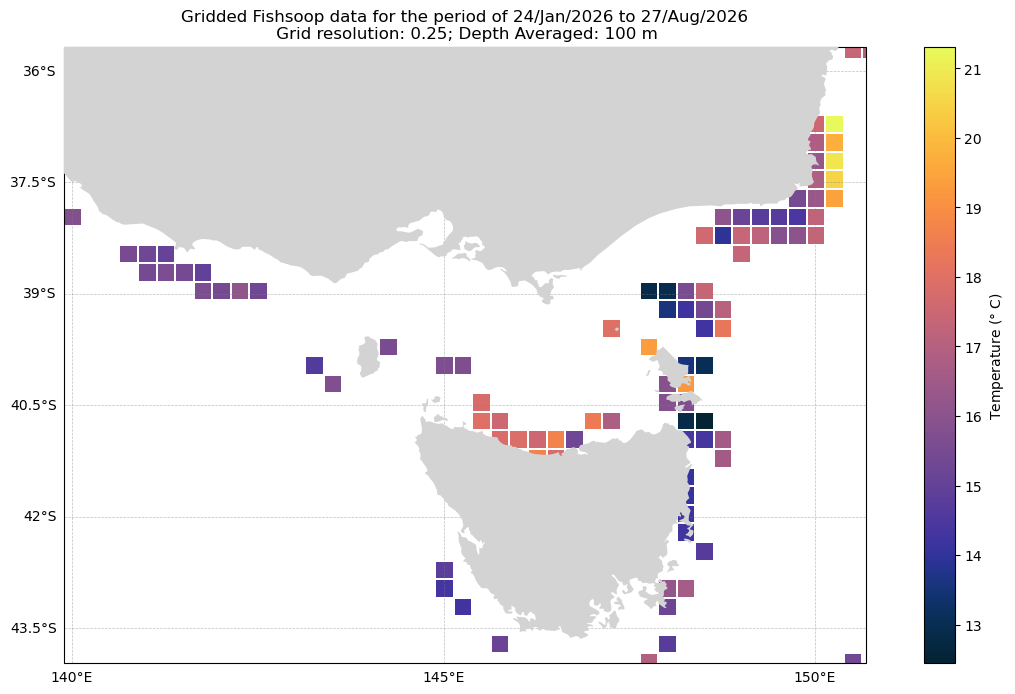

In [16]:
fig, ax = make_map(lon_min, lon_max, lat_min, lat_max)

pcm = ax.pcolormesh(
                lon_edges,
                lat_edges,
                bin_avg,
                shading='auto',
                cmap=cmo.thermal,
                edgecolors='white',
                linewidth=0.1,
                transform=ccrs.PlateCarree(),
                zorder=-1
    )

plt.title('Gridded Fishsoop data for the period of %s to %s\n Grid resolution: %s; Depth Averaged: %s m' % (st_date, nd_date, grid_resol, avg_depth))
plt.colorbar(pcm, ax=ax, label=r'Temperature ($\degree$ C)')
